# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd
df_15 = pd.read_csv("arquivoaula15.csv", index_col="Unnamed: 0")
display(df_15)

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
GAPDH,31,3,20,13,14,33,10,22,26,19,10,19,12,7,10,21,21,32,3,9
ICAM,36,14,15,34,10,36,5,12,23,62,5,22,50,31,30,33,49,48,5,12
MCP1,11,5,5,2,3,1,1,8,10,8,2,3,6,7,4,6,8,6,1,2
SDC1,37,2,16,27,6,30,7,5,9,28,4,5,27,20,11,23,33,13,3,4
TGFB,24,12,14,26,10,20,10,14,18,52,7,15,30,14,30,31,17,23,7,16


In [59]:
def medidas_tendencia(x):
    return {
        "media": x.mean(),
        "mediana": x.median(),
        "moda": x.mode().iloc[0]
    }


In [65]:
medidas_serina = medidas_tendencia(serina)
medidas_serina
print(serina)

GAPDH    21
ICAM     33
MCP1      6
SDC1     23
TGFB     31
Name: S, dtype: int64


In [66]:
terceiro_gene = df_15.iloc[2]["S"]
print("Terceiro gene:", terceiro_gene)

Terceiro gene: 6


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [25]:
df_15

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
GAPDH,31,3,20,13,14,33,10,22,26,19,10,19,12,7,10,21,21,32,3,9
ICAM,36,14,15,34,10,36,5,12,23,62,5,22,50,31,30,33,49,48,5,12
MCP1,11,5,5,2,3,1,1,8,10,8,2,3,6,7,4,6,8,6,1,2
SDC1,37,2,16,27,6,30,7,5,9,28,4,5,27,20,11,23,33,13,3,4
TGFB,24,12,14,26,10,20,10,14,18,52,7,15,30,14,30,31,17,23,7,16


In [22]:
def amplitude(x):
    return x.max() - x.min()

In [74]:
resultado_a = amplitude(df_15["I"])
print("Amplitude Isoleucina:", resultado_a )

Amplitude Isoleucina: 17


In [77]:
resultado_a2 = amplitude(df_15.iloc[-1])
print("Amplitude Último Gene:", resultado_a2)

Amplitude Último Gene: 45


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [105]:
def quartis(x):
    return x.quantile([0.25, 0.50, 0.75])

In [106]:
quartis(df_15["M"])

0.25    4.0
0.50    5.0
0.75    7.0
Name: M, dtype: float64

In [107]:
quartis(df_15.iloc[0])

0.25    10.00
0.50    16.50
0.75    21.25
Name: GAPDH, dtype: float64

## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [108]:
def intervalo_interquartil(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    return q3 - q1

In [111]:
resultado_iq = intervalo_interquartil(df_15["E"])
print("Intervalo Interquartil Ácido Glutamico:", resultado_iq)

Intervalo Interquartil Ácido Glutamico: 14.0


In [113]:
resultado_iq2 = intervalo_interquartil(df_15.iloc[-2])
print("Intervalo Interquartil Penúltimo Gene:", resultado_iq2)

Intervalo Interquartil Penúltimo Gene: 22.0


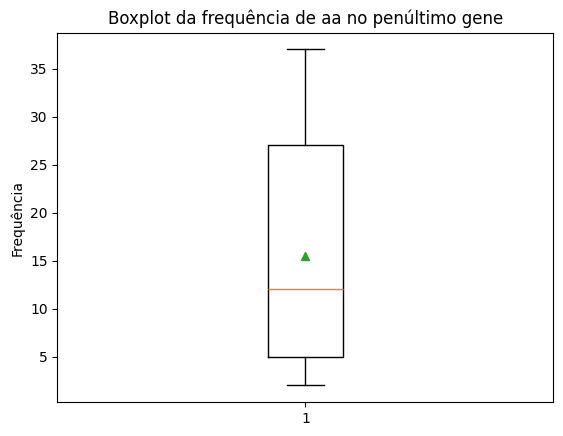

In [114]:
import matplotlib.pyplot as plt

gene_penultimo = df_15.iloc[-2]

plt.boxplot(gene_penultimo, vert=True, showmeans=True)
plt.title("Boxplot da frequência de aa no penúltimo gene")
plt.ylabel("Frequência")
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [115]:
def variancia_amostral(x):
    return x.var(ddof=1)

In [120]:
resultado_varianca = variancia_amostral(df_15["P"])
print("Variância Prolina:", resultado_varianca)

Variância Prolina: 296.0


In [123]:
resultado_variancia2 = variancia_amostral(df_15.iloc[2])
print("Variância Terceiro Gene:", resultado_variancia2)

Variância Terceiro Gene: 9.418421052631578


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [36]:
def desvio_padrao(x):
    return x.std(ddof=1)

In [126]:
resultado_dp = desvio_padrao(df_15["W"])
print("Desvio Triptofano:", resultado_dp)

Desvio Triptofano: 2.280350850198276


In [127]:
resultado_dp2 = desvio_padrao(df_15.iloc[-1])
print("Desvio Gene Index -1:", resultado_dp2)

Desvio Gene Index -1: 10.674613267985526


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [42]:
def coeficiente_variacao(x):
    return (x.std(ddof=1) / x.mean()) * 100

In [129]:
resultado_coef = coeficiente_variacao(df_15["L"])
print("Coeficiente Leucina:", resultado_coef)

Coeficiente Leucina: 66.89269946065126


In [130]:
resultado_coef2 = coeficiente_variacao(df_15.iloc[1])
print("Coeficiente Gene index 1:", resultado_coef2)

Coeficiente Gene index 1: 63.92024868194125


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [131]:
def medidas_resumo(x):
    return {
        "minimo": x.min(),
        "Q1": x.quantile(0.25),
        "mediana": x.median(),
        "media": x.mean(),
        "Q3": x.quantile(0.75),
        "maximo": x.max(),
        "amplitude": x.max() - x.min(),
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "variancia": x.var(ddof=1),
        "desvio_padrao": x.std(ddof=1),
        "coef_var_%": (x.std(ddof=1) / x.mean()) * 100
    }

In [132]:
medidas_resumo(df_15["L"])

{'minimo': np.int64(8),
 'Q1': np.float64(19.0),
 'mediana': np.float64(28.0),
 'media': np.float64(33.8),
 'Q3': np.float64(52.0),
 'maximo': np.int64(62),
 'amplitude': np.int64(54),
 'IQR': np.float64(33.0),
 'variancia': np.float64(511.19999999999993),
 'desvio_padrao': np.float64(22.609732417700126),
 'coef_var_%': np.float64(66.89269946065126)}

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [134]:
def gene_maior_cv(df):
    cv = (df.std(axis=1, ddof=1) / df.mean(axis=1)) * 100
    return cv.idxmax(), cv.max()

In [136]:
resultado_gene = gene_maior_cv(df_15)
print(resultado_gene)

('SDC1', np.float64(74.46249328329118))


C:\Users\julia\AppData\Local\Temp\ipykernel_8224\3233012214.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_15.T, labels=df_15.index)


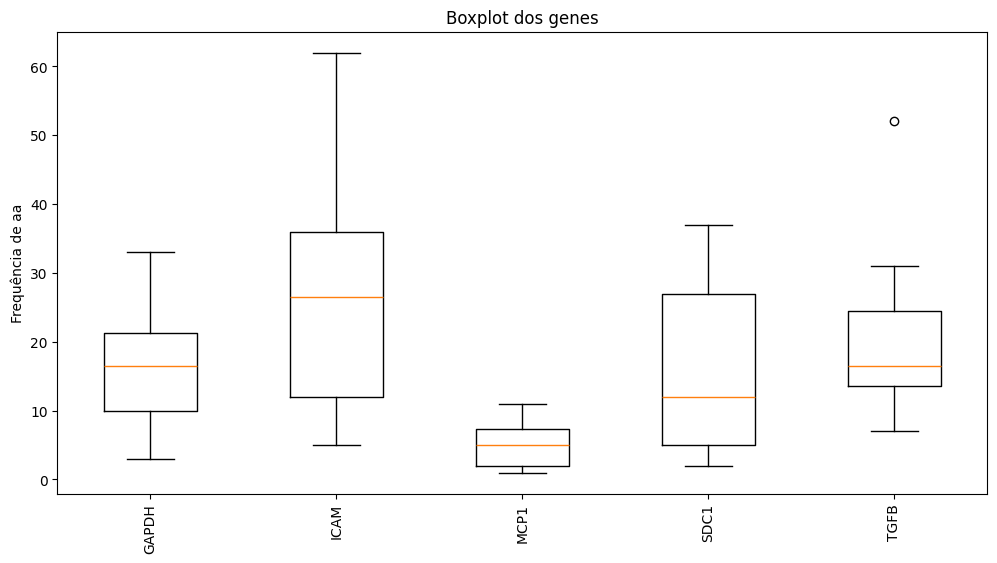

In [137]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.boxplot(df_15.T, labels=df_15.index)
plt.xticks(rotation=90)
plt.ylabel("Frequência de aa")
plt.title("Boxplot dos genes")
plt.show()

R = Os dados são concordantes. O gene com maior coeficiente de variação apresenta apresentar maior dispersão relativa dos valores.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [143]:
def aa_maior_cv(df):
    cv = (df.std(axis=0, ddof=1) / df.mean(axis=0)) * 100
    return cv.idxmax(), cv.max()

In [141]:
resultado_aa_maior = aa_maior_cv(df_15)
print(resultado_aa_maior)

('C', np.float64(75.69125885243729))


C:\Users\julia\AppData\Local\Temp\ipykernel_8224\2713009700.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_15, labels=df_15.columns)


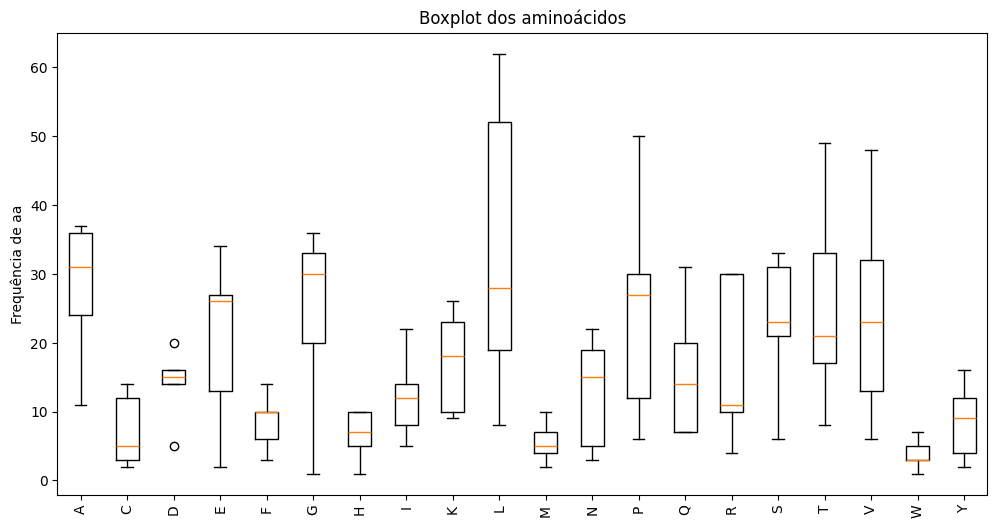

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.boxplot(df_15, labels=df_15.columns)
plt.xticks(rotation=90)
plt.ylabel("Frequência de aa")
plt.title("Boxplot dos aminoácidos")
plt.show()

R =  Os dados concordam parcialmente. O CV é normalizado pela média, então um aminoácido com média baixa pode ter CV alto mesmo sem grande dispersão visível, como é o caso da leucina. 
